# Statistics

In [1]:
from collections import defaultdict
from pathlib import Path
import csv
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = Path("results/results.csv")
COMPARABLE_AVX2_HASHES = {"mask"}

df = pd.read_csv(RESULTS_PATH)

df["N"] = pd.to_numeric(df["N"], errors="coerce")
df["P"] = pd.to_numeric(df["P"], errors="coerce")
df["PARTITION_TIME"] = pd.to_numeric(df["PARTITION_TIME"], errors="coerce")
df["GLOBAL_TIME"] = pd.to_numeric(df["GLOBAL_TIME"], errors="coerce")

def filter_avx2_comparisons(frame):
    return frame[(frame["EXEC_TYPE"] != "avx2") | (frame["HASH"].isin(COMPARABLE_AVX2_HASHES))].copy()

df_compare = filter_avx2_comparisons(df)
excluded_rows = len(df) - len(df_compare)

exec_type_names = sorted(df["EXEC_TYPE"].dropna().unique())
exec_type_palette = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
]
exec_type_colors = {
    exec_type: exec_type_palette[idx % len(exec_type_palette)]
    for idx, exec_type in enumerate(exec_type_names)
}

print(f"[Loaded {df.shape[0]} different runs from {RESULTS_PATH}]")
print("Distinct values for each column:")
print(f"  EXEC_TYPE: {df['EXEC_TYPE'].unique()}")
print(f"  HASH: {df['HASH'].unique()}")
print(f"  N: {df['N'].unique()}")
print(f"  P: {df['P'].unique()}")
print(f"  Comparison rule: avx2 included only for HASH in {sorted(COMPARABLE_AVX2_HASHES)}")
print(f"  Comparison dataset rows: {df_compare.shape[0]} (excluded {excluded_rows} unsupported avx2 rows)")
print(f"  EXEC_TYPE colors: {exec_type_colors}")



[Loaded 189 different runs from results/results.csv]
Distinct values for each column:
  EXEC_TYPE: ['plain_novec' 'plain_vec' 'avx2']
  HASH: ['mask' 'xorshift' 'fmix32fold']
  N: [  100000  1000000 10000000]
  P: [  16   32   64  128  256  512 1024 2048 4096]
  Comparison rule: avx2 included only for HASH in ['mask']
  Comparison dataset rows: 189 (excluded 0 unsupported avx2 rows)
  EXEC_TYPE colors: {'avx2': 'tab:blue', 'plain_novec': 'tab:orange', 'plain_vec': 'tab:green'}


# Checksum validation

In [2]:
summary_rows = []
df_grouped = df_compare.groupby(["N", "P", "HASH"])
valid_counter = 0
for (N, P, HASH), subdf in df_grouped:
    checksums = subdf["CHECKSUM"].unique()
    is_valid = len(checksums) == 1
    valid_counter += 1 if is_valid else 0

    summary_rows.append({
        "N": N,
        "P": P,
        "HASH": HASH,
        "N_CHECKSUMS": len(checksums),
        "CHECKSUMS": ", ".join(map(str, checksums))
    })

if valid_counter == df_grouped.ngroups:
    print(f"[OK] All groups have a single unique checksum")
else:
    print(f"[FAIL] Only {valid_counter}/{df_grouped.ngroups} groups have a single unique checksum")

checksum_validation_df = pd.DataFrame(summary_rows)
checksum_validation_df


[OK] All groups have a single unique checksum


,N,P,HASH,N_CHECKSUMS,CHECKSUMS
0,100000,16,fmix32fold,1,170350642475120341615477361625599108977
1,100000,16,mask,1,167721051258154842028923385100699716177
2,100000,16,xorshift,1,640297181273200996516189456180651545625
3,100000,32,fmix32fold,1,21869188240084406419744193982774566145
4,100000,32,mask,1,235082523872698469814010259685181055441
...,...,...,...,...,...
76,10000000,2048,mask,1,174751143964903068612950250125392416377
77,10000000,2048,xorshift,1,1036587642463740155915193285507711869266
78,10000000,4096,fmix32fold,1,665781616751523650610711143078283471570
79,10000000,4096,mask,1,118826605224740459825505141072278363769


# Average metrics

In [3]:
display(
    (
        df_compare.groupby(["HASH", "EXEC_TYPE", "P"], as_index=False)
        .agg(
            mean_throughput=("THROUGHPUT", "mean"),
            mean_partition_time=("PARTITION_TIME", "mean"),
            mean_global_time=("GLOBAL_TIME", "mean"),
        )
        .sort_values(["HASH", "EXEC_TYPE"])
        .reset_index(drop=True)
    )
)

,HASH,EXEC_TYPE,P,mean_throughput,mean_partition_time,mean_global_time
0,fmix32fold,plain_novec,16,4.585527e+08,0.016230,1.445833
1,fmix32fold,plain_novec,32,4.549940e+08,0.016267,1.423580
2,fmix32fold,plain_novec,64,4.547178e+08,0.016263,1.440913
3,fmix32fold,plain_novec,128,4.514544e+08,0.016257,1.447023
4,fmix32fold,plain_novec,256,4.556555e+08,0.016173,1.450460
...,...,...,...,...,...,...
58,xorshift,plain_vec,256,8.986675e+08,0.008277,1.430847
59,xorshift,plain_vec,512,8.736995e+08,0.008247,1.430017
60,xorshift,plain_vec,1024,8.901854e+08,0.008223,1.420687
61,xorshift,plain_vec,2048,8.876284e+08,0.008257,1.416113


# PARTITION_TIME vs P

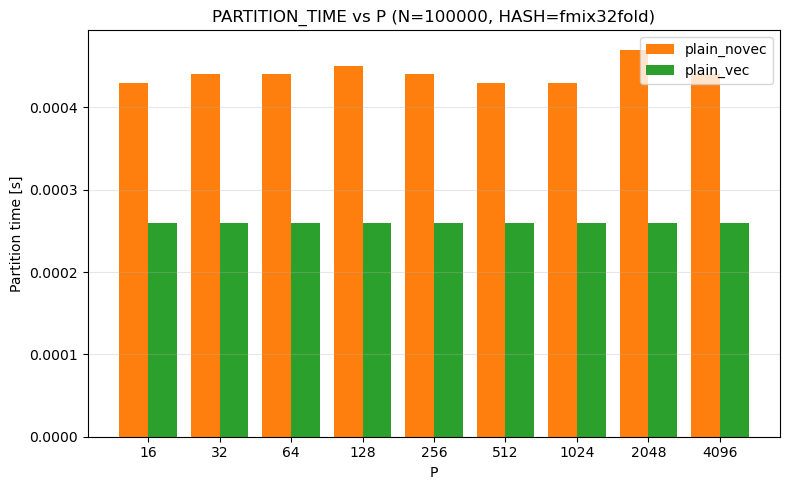

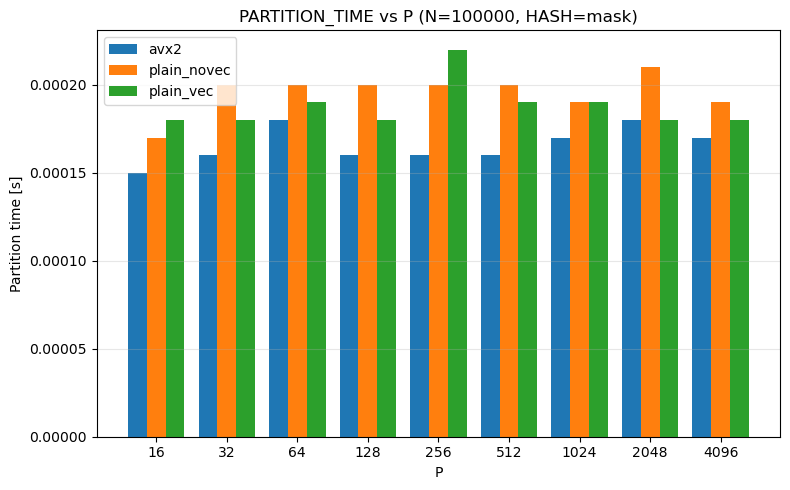

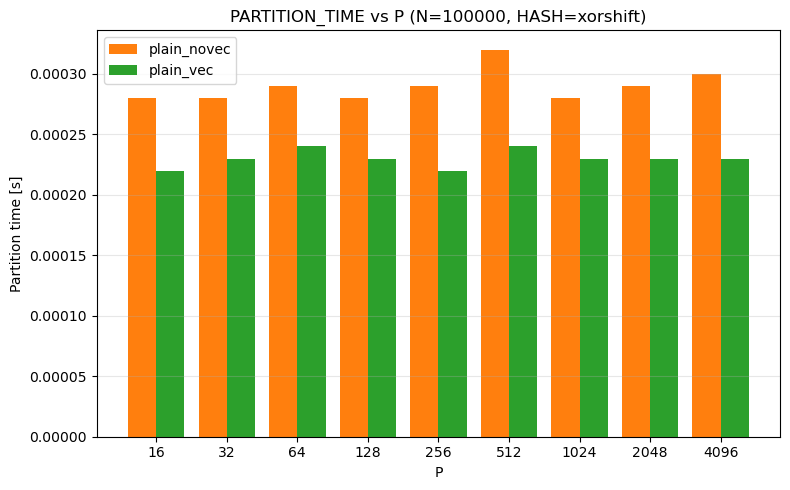

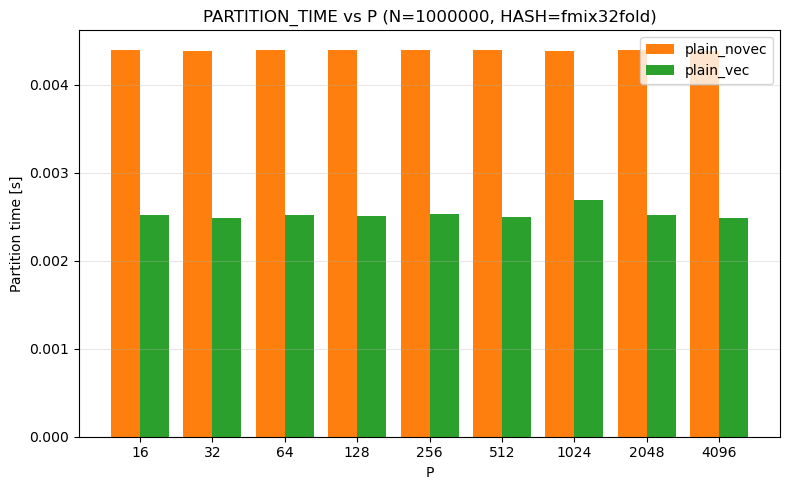

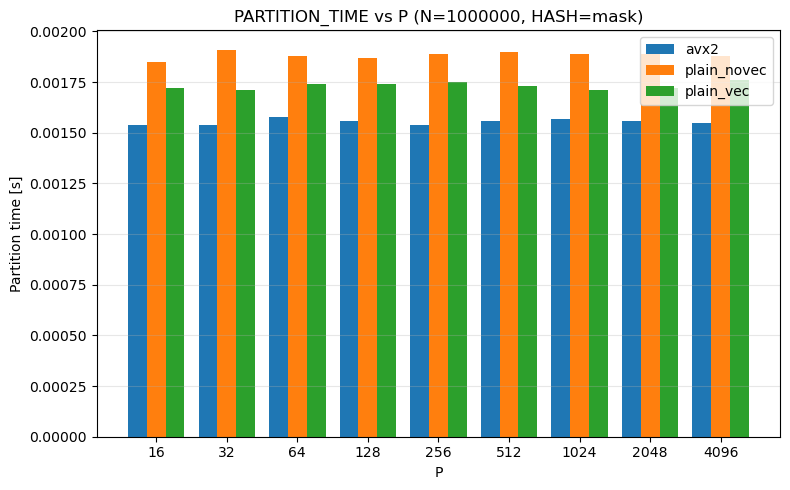

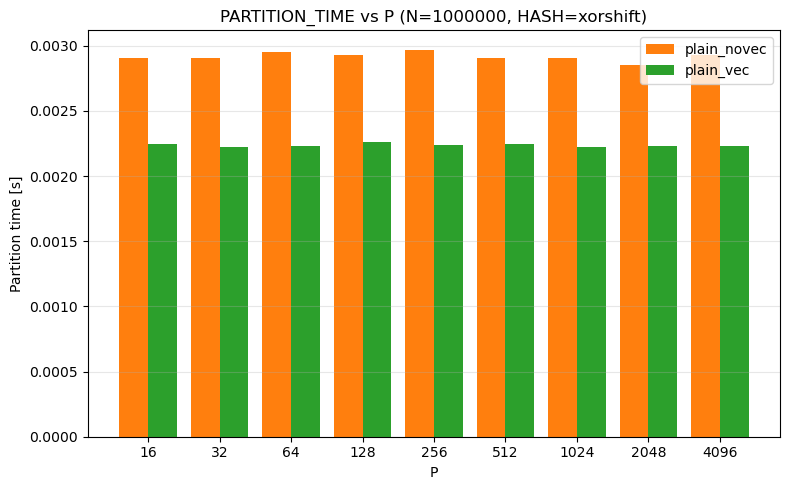

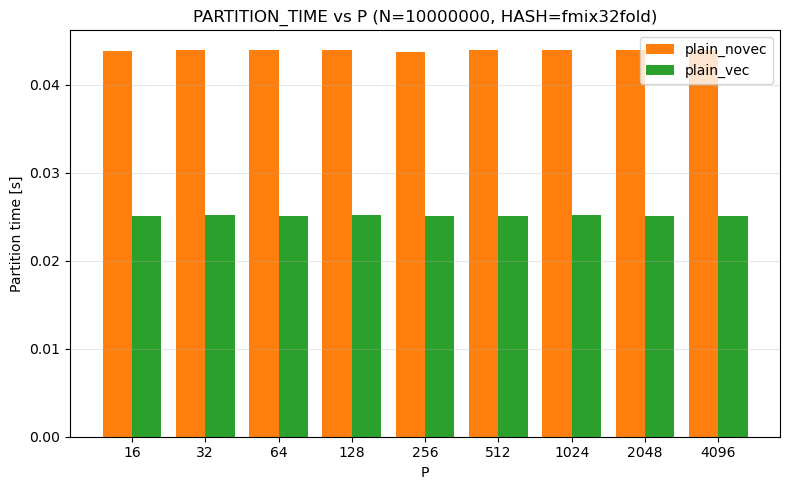

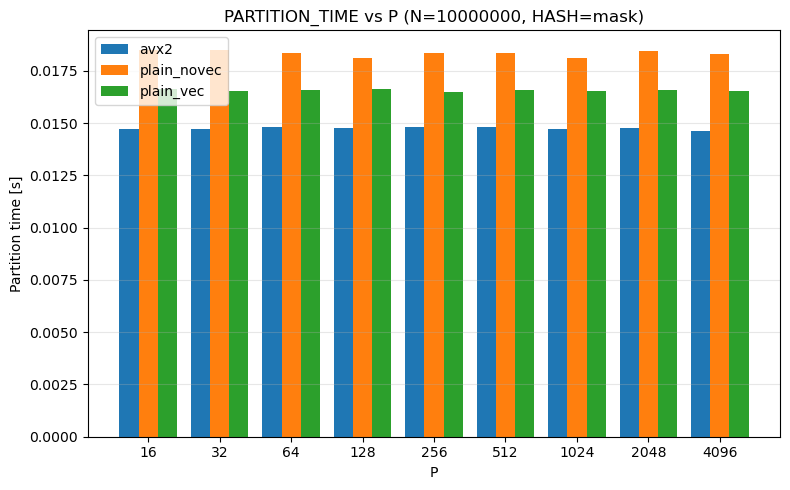

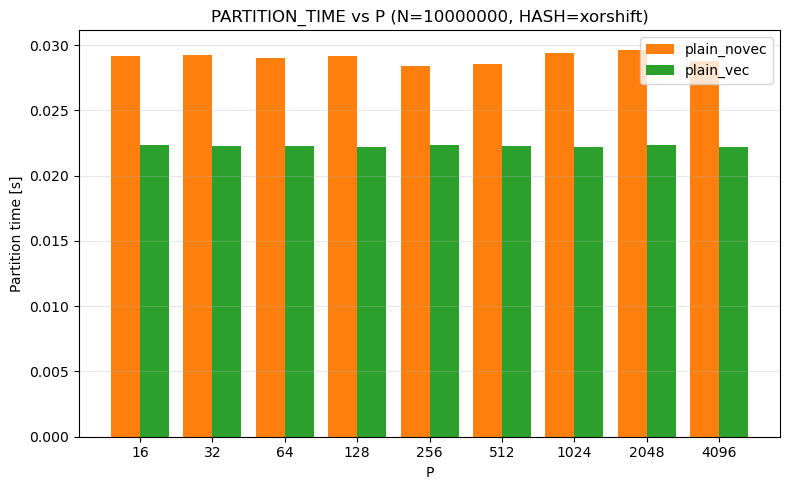

In [4]:
for (fixed_N, fixed_HASH), subdf in df_compare.groupby(["N", "HASH"]):
    plt.figure(figsize=(8, 5))

    p_values = sorted(subdf["P"].unique())
    x_positions = list(range(len(p_values)))
    exec_types = sorted(subdf["EXEC_TYPE"].dropna().unique())

    if not exec_types:
        continue

    bar_width = 0.8 / len(exec_types)

    for idx, exec_type in enumerate(exec_types):
        g = subdf[subdf["EXEC_TYPE"] == exec_type].sort_values("P")
        values_by_p = g.set_index("P")["PARTITION_TIME"].to_dict()
        heights = [values_by_p.get(p, float("nan")) for p in p_values]
        offsets = [
            x + (idx - (len(exec_types) - 1) / 2) * bar_width
            for x in x_positions
        ]

        plt.bar(
            offsets,
            heights,
            width=bar_width,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            label=exec_type,
        )

    plt.xticks(x_positions, p_values)
    plt.xlabel("P")
    plt.ylabel("Partition time [s]")
    plt.title(f"PARTITION_TIME vs P (N={fixed_N}, HASH={fixed_HASH})")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# THROUGHPUT vs P

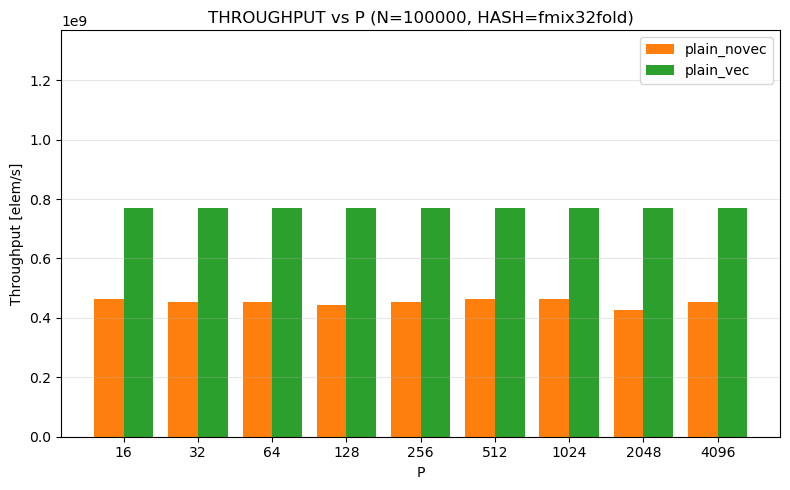

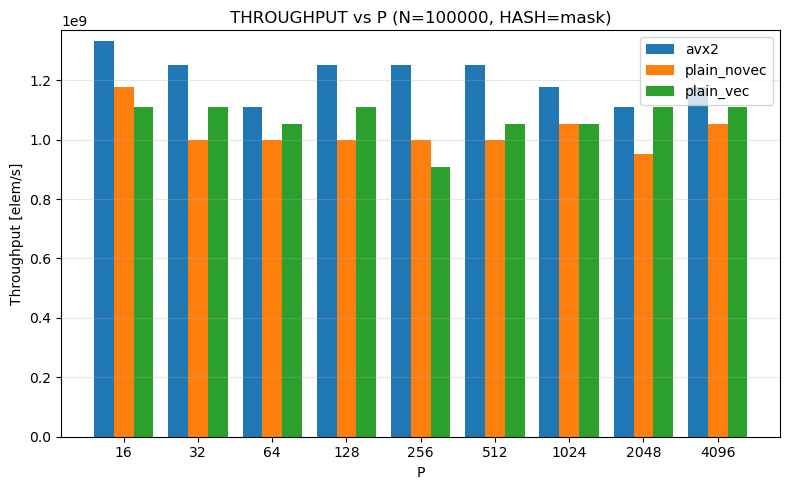

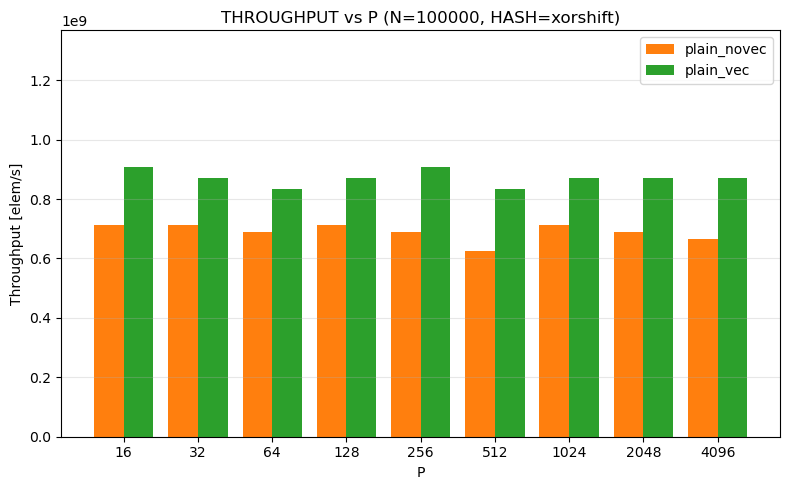

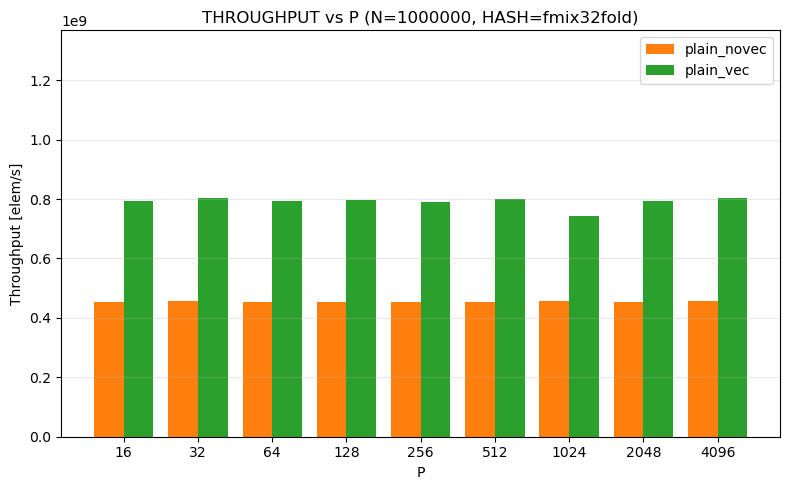

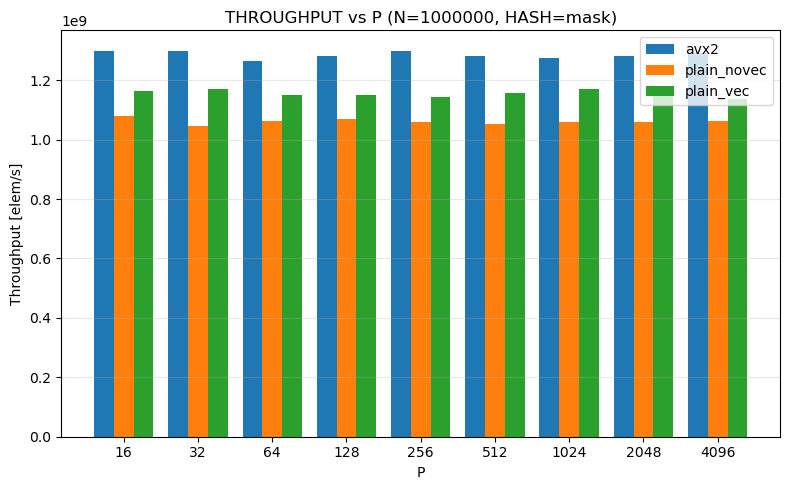

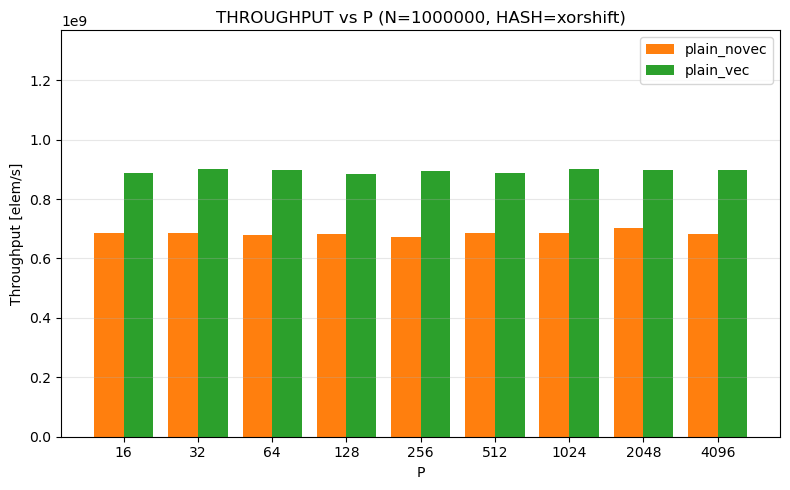

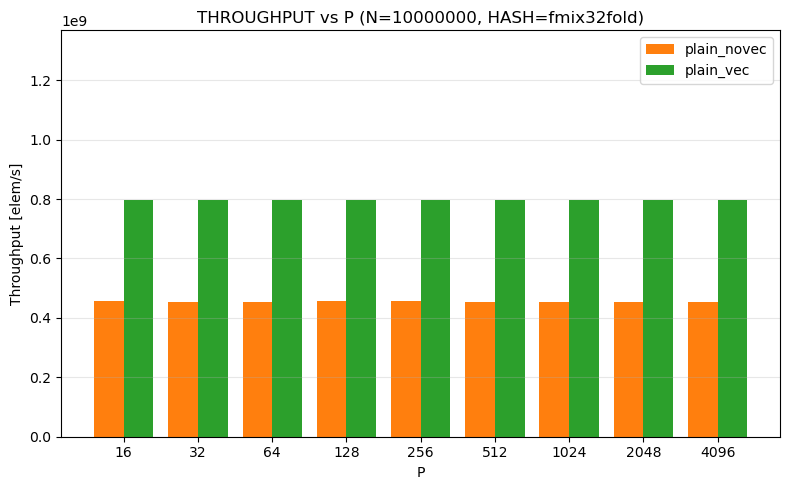

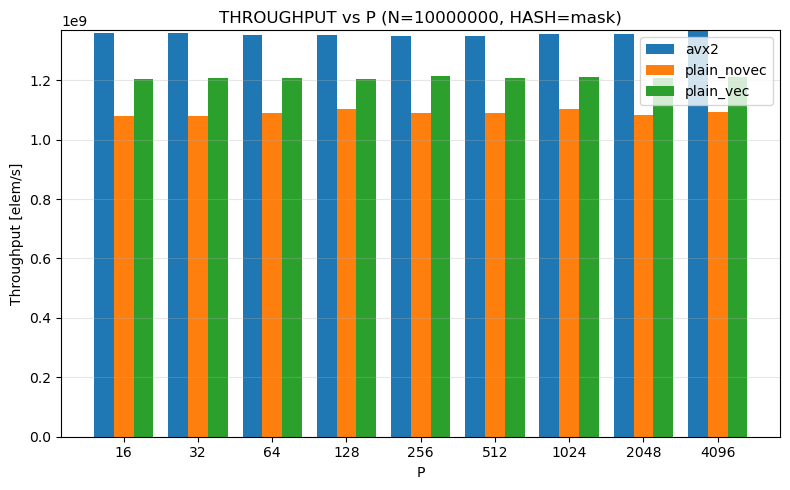

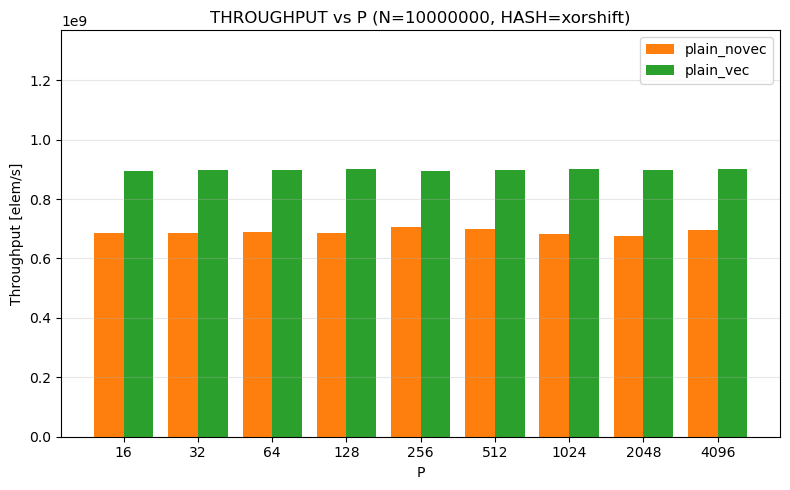

In [5]:
GLOBAL_THROUGHPUT_YMAX = df["THROUGHPUT"].max()
for (fixed_N, fixed_HASH), subdf in df_compare.groupby(["N", "HASH"]):
    plt.figure(figsize=(8, 5))

    p_values = sorted(subdf["P"].unique())
    x_positions = list(range(len(p_values)))
    exec_types = sorted(subdf["EXEC_TYPE"].dropna().unique())

    if not exec_types:
        continue

    bar_width = 0.8 / len(exec_types)
    max_candidates = []

    for idx, exec_type in enumerate(exec_types):
        g = subdf[subdf["EXEC_TYPE"] == exec_type].sort_values("P")
        values_by_p = g.set_index("P")["THROUGHPUT"].to_dict()
        heights = [values_by_p.get(p, float("nan")) for p in p_values]
        offsets = [
            x + (idx - (len(exec_types) - 1) / 2) * bar_width
            for x in x_positions
        ]

        for value in heights:
            if pd.notna(value):
                max_candidates.append(value)

        plt.bar(
            offsets,
            heights,
            width=bar_width,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            label=exec_type,
        )

    if pd.notna(GLOBAL_THROUGHPUT_YMAX):
        plt.ylim(0, GLOBAL_THROUGHPUT_YMAX)

    plt.xticks(x_positions, p_values)
    plt.xlabel("P")
    plt.ylabel("Throughput [elem/s]")
    plt.title(f"THROUGHPUT vs P (N={fixed_N}, HASH={fixed_HASH})")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# SPEEDUP vs P

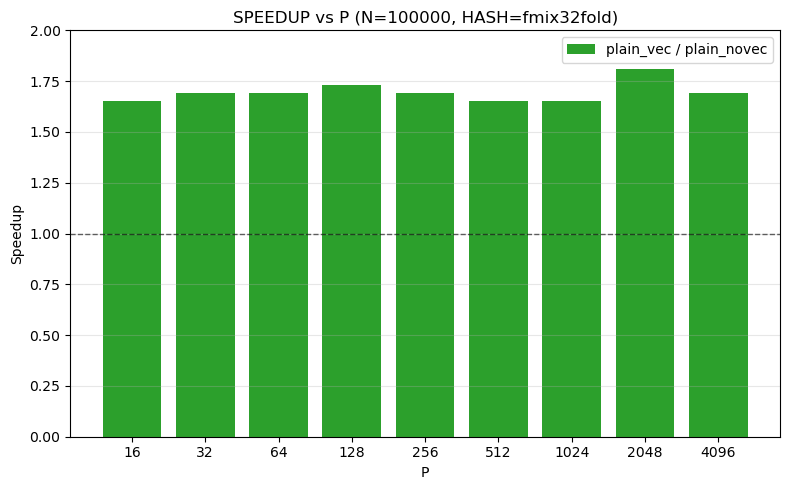

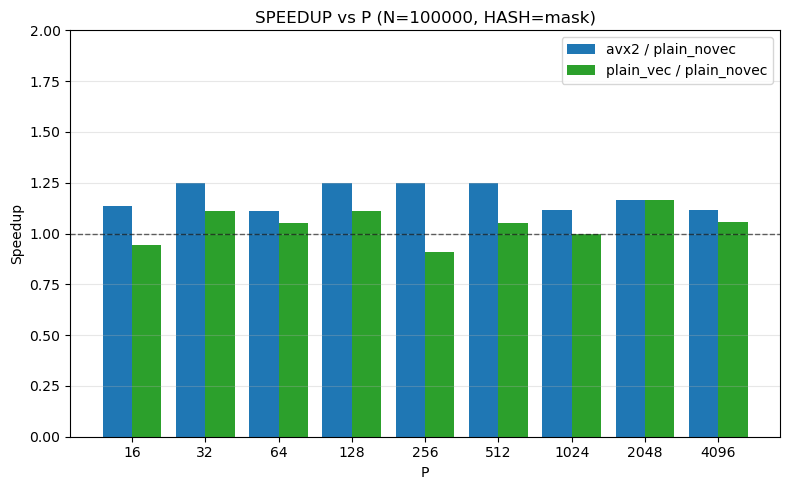

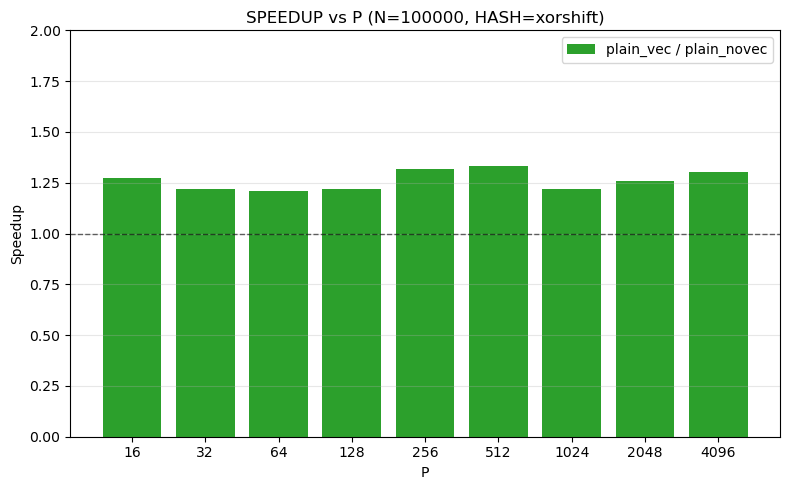

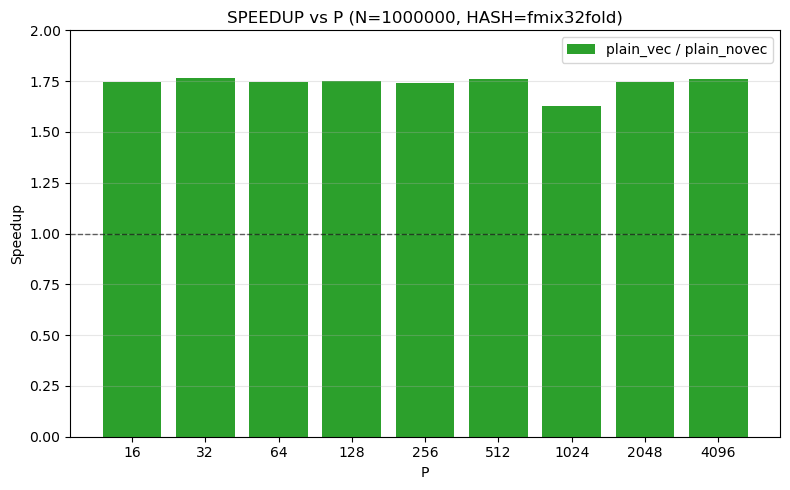

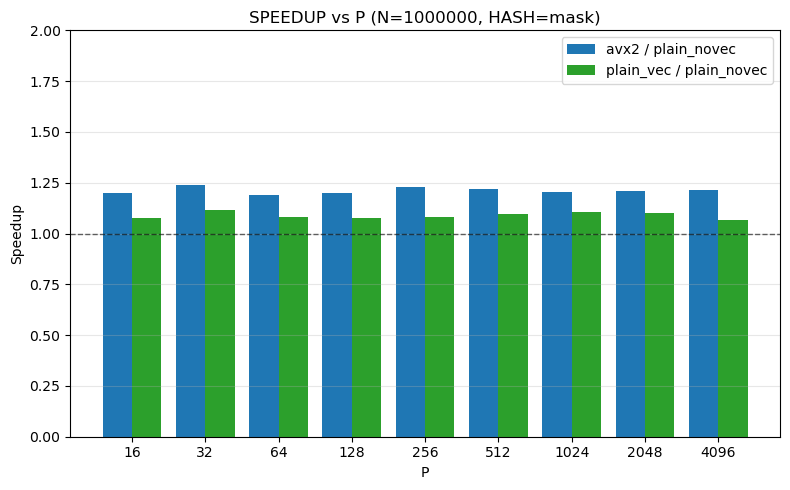

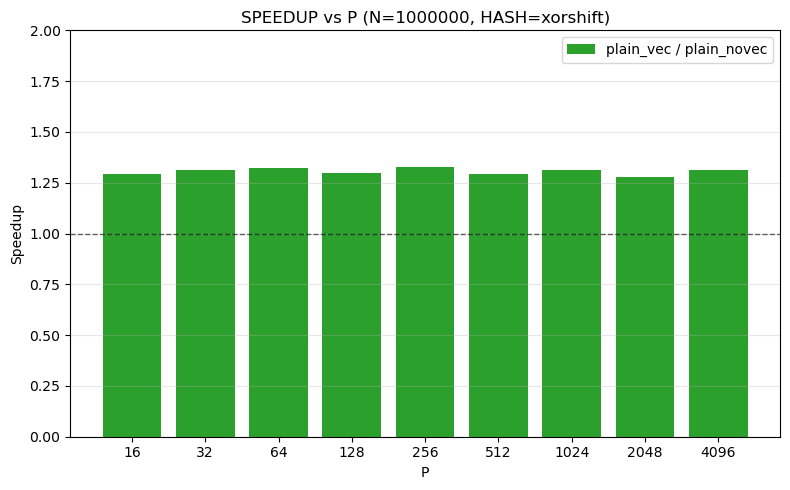

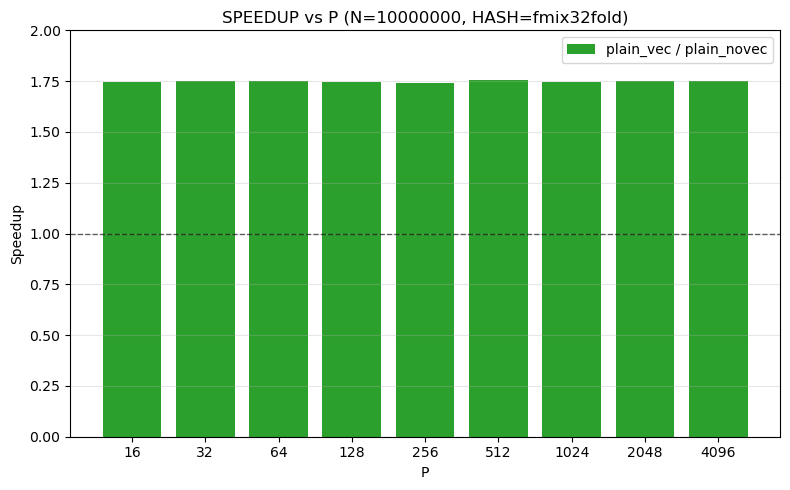

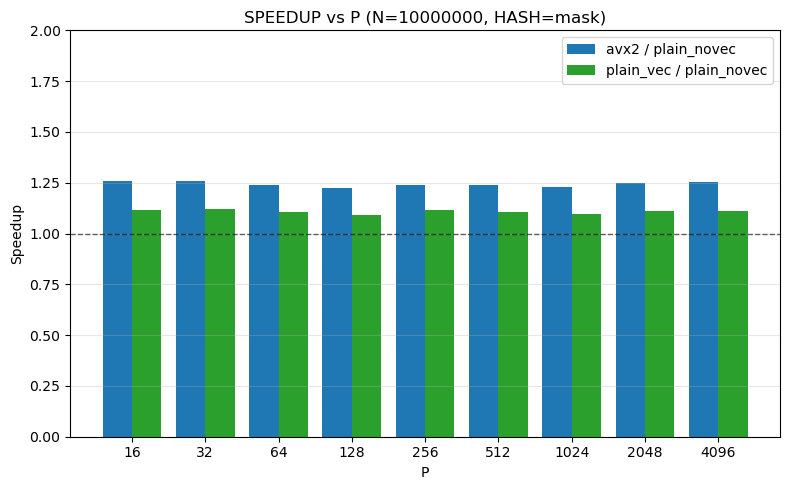

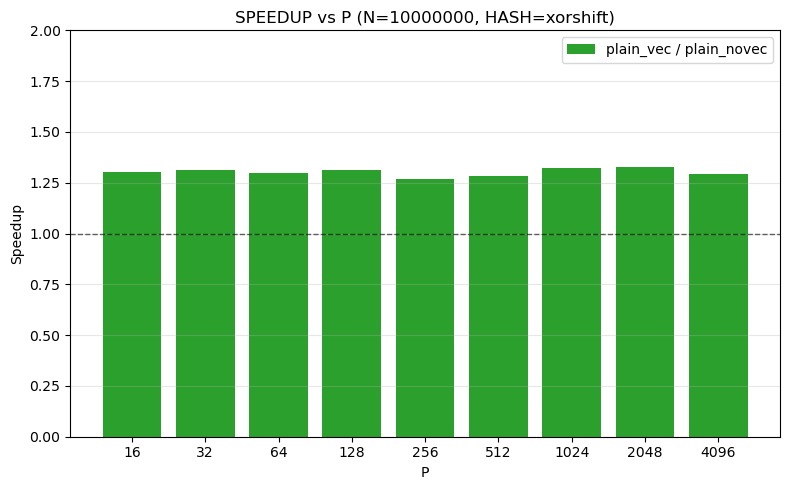

In [6]:
for (fixed_N, fixed_HASH), subdf in df_compare.groupby(["N", "HASH"]):
    pivot = subdf.pivot(index="P", columns="EXEC_TYPE", values="THROUGHPUT").sort_index()

    if "plain_novec" not in pivot.columns:
        continue

    speedup_cols = [col for col in pivot.columns if col != "plain_novec"]
    if not speedup_cols:
        continue

    p_values = list(pivot.index)
    x_positions = list(range(len(p_values)))
    bar_width = 0.8 / len(speedup_cols)

    plt.figure(figsize=(8, 5))
    max_candidates = []

    for idx, col in enumerate(speedup_cols):
        speedup = (pivot[col] / pivot["plain_novec"]).reindex(p_values)
        offsets = [
            x + (idx - (len(speedup_cols) - 1) / 2) * bar_width
            for x in x_positions
        ]

        speedup_values = list(speedup.values)
        for value in speedup_values:
            if pd.notna(value):
                max_candidates.append(value)

        plt.bar(
            offsets,
            speedup_values,
            width=bar_width,
            color=exec_type_colors.get(col, "tab:gray"),
            label=f"{col} / plain_novec",
        )

    if max_candidates and max(max_candidates) < 2:
        plt.ylim(0, 2)

    plt.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    plt.xticks(x_positions, p_values)
    plt.xlabel("P")
    plt.ylabel("Speedup")
    plt.title(f"SPEEDUP vs P (N={fixed_N}, HASH={fixed_HASH})")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
